# 문자 단위 GPT 실습 (한국어)

김유정 단편 corpus로 문자 단위 GPT를 학습하며 Transformer 구조를 확인함

- 데이터: 위키문헌 퍼블릭 도메인 김유정 단편 8편 (텍스트 파일 1개, 다운로드 후 업로드해서 사용)
- 코드: Andrej Karpathy의 [minGPT](https://github.com/karpathy/minGPT) (MIT License) 를 교육용으로 단순화해서 이 노트북 안에 직접 포함함 (외부 저장소 clone 없이 노트북 파일 하나로 실행 가능)


표시 기준

- [필수 이해] : 꼭 이해하고 넘어가야 하는 부분, 보고서에도 필요함
- [개념 확인] : 알아두면 좋은 부분, 자세히 몰라도 실습은 진행 가능
- [참고 코드] : 구현 세부사항, 그냥 넘어가도 무방함


## 1. 환경 준비

In [ ]:
import os
import math
import time
import random
from dataclasses import dataclass
from collections import defaultdict

import numpy as np
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.utils.data import Dataset
from torch.utils.data.dataloader import DataLoader
import matplotlib.pyplot as plt


def set_seed(seed):
    """실험 재현을 위한 랜덤 시드 고정"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


## 2. 실행 설정

In [ ]:
# FAST_RUN = True  : 몇 분 안에 전체 흐름을 빠르게 확인 (품질은 낮음, 처음 실행 추천)
# FAST_RUN = False : 정식 학습 (품질 좋은 생성 결과 확인, 시간이 더 걸림 - GPU 권장)
FAST_RUN = True

if FAST_RUN:
    MAX_ITERS = 100
    SAMPLE_EVERY = 50
    SAMPLE_LENGTH = 200
else:
    MAX_ITERS = 2000
    SAMPLE_EVERY = 500
    SAMPLE_LENGTH = 500

set_seed(3407)


## 3. 데이터 준비 (김유정 단편)

위키문헌 퍼블릭 도메인 작품 8편을 정제·병합한 corpus

1. 아래 링크에서 input_kr.txt 파일 다운로드: [input_kr.txt 다운로드](https://raw.githubusercontent.com/mue76/skala-llm-transformer/main/input_kr.txt)
2. 다음 셀 실행 → 파일 선택 창에서 방금 받은 input_kr.txt 업로드


In [ ]:
DATA_PATH = "input_kr.txt"

if not os.path.exists(DATA_PATH):
    from google.colab import files
    print(f"'{DATA_PATH}' 파일 선택 후 업로드")
    uploaded = files.upload()
    assert DATA_PATH in uploaded, f"'{DATA_PATH}' 파일 업로드 필요"

with open(DATA_PATH, "r", encoding="utf-8") as f:
    text = f.read()

print(f"전체 문자 수: {len(text):,}")
print(f"고유 문자 수: {len(set(text))}")
print(text[:300])


## 4. 문자 토큰화와 CharDataset  [필수 이해] 문자 토큰화

- 토큰 = 문자 1개. stoi는 문자를 정수로, itos는 정수를 문자로 바꿔줌
- 입력 x = 128글자, 정답 y = 한 글자씩 밀린 128글자
- 과제: 모든 위치에서 다음 문자 맞히기


In [ ]:
class CharDataset(Dataset):
    """corpus를 (입력 x, 정답 y) 문자 배치로 잘라 공급."""

    def __init__(self, data, block_size=128):
        chars = sorted(list(set(data)))          # 고유 문자 목록 = vocab
        self.vocab_size = len(chars)
        self.block_size = block_size
        self.data = data

        self.stoi = {ch: i for i, ch in enumerate(chars)}  # 문자 → 정수
        self.itos = {i: ch for i, ch in enumerate(chars)}  # 정수 → 문자

        print(f"데이터 {len(data):,}자, 고유 문자 {self.vocab_size:,}개")

    def __len__(self):
        return len(self.data) - self.block_size

    def __getitem__(self, idx):
        # block_size+1 글자를 잘라 정수로
        chunk = self.data[idx : idx + self.block_size + 1]
        dix = [self.stoi[s] for s in chunk]

        x = torch.tensor(dix[:-1], dtype=torch.long)  # 입력
        y = torch.tensor(dix[1:], dtype=torch.long)   # 한 칸 밀린 정답
        return x, y


train_dataset = CharDataset(text, block_size=128)

데이터 97,708자, 고유 문자 1,271개


In [ ]:
# [필수 이해] 입력 x와 정답 y
# 토큰화 확인: 같은 문자 → 항상 같은 정수
for ch in text[:5]:
    print(f"'{ch}' → {train_dataset.stoi[ch]}")

x_sample, y_sample = train_dataset[0]
print("\nx shape:", x_sample.shape, "/ y shape:", y_sample.shape)
print("\n입력 x :", "".join(train_dataset.itos[int(i)] for i in x_sample[:40]))
print("정답 y :", "".join(train_dataset.itos[int(i)] for i in y_sample[:40]))


'오' → 836
'늘' → 272
'도' → 316
' ' → 1
'또' → 377

x shape: torch.Size([128]) / y shape: torch.Size([128])

입력 x : 오늘도 또 우리 수탉이 막 쫓기었다. 내가 점심을 먹고 나무를 하러 갈 
정답 y : 늘도 또 우리 수탉이 막 쫓기었다. 내가 점심을 먹고 나무를 하러 갈 양


## 5. Transformer 아키텍처

| 구성 요소 | 역할 | 구분 |
|---|---|---|
| GPTConfig | 모델 크기 설정 (6층, 6헤드, 192차원) | 설정 |
| SelfAttention | Self-Attention의 핵심 로직 — 어디를 참조할지 계산 (인코더형, 마스크 없음) | 개념 확인 |
| CausalSelfAttention | SelfAttention을 상속 + 미래 위치를 가리는 causal mask만 추가 (GPT/디코더형) | 필수 이해 |
| Block | Attention + MLP | 개념 확인 |
| GPT | 임베딩 → Block×6 → 다음 문자 확률 | 필수 이해 |


### 5.1 모델 설정 (GPTConfig)


In [ ]:
@dataclass
class GPTConfig:
    vocab_size: int            # 고유 문자 수 (데이터에서 결정)
    block_size: int = 128      # 한 번에 볼 수 있는 최대 문맥 길이
    n_layer: int = 6           # Transformer Block 수      (gpt-mini)
    n_head: int = 6            # Attention 헤드 수          (gpt-mini)
    n_embd: int = 192          # 임베딩 벡터 차원           (gpt-mini)
    embd_pdrop: float = 0.1    # 이하 dropout 비율 (과적합 완화)
    resid_pdrop: float = 0.1
    attn_pdrop: float = 0.1


### 5.2 Self-Attention — Transformer의 핵심  [개념 확인] Q, K, V / Multi-Head Attention

Self-Attention은 각 위치가 문장 안의 다른 위치들과 얼마나 관련 있는지 계산해서,
그 관련도(가중치)만큼 정보를 섞어주는 장치. Transformer를 Transformer답게 만드는 핵심 연산임.

1. 입력에서 Query, Key, Value 생성
2. Query·Key 내적으로 관련도 점수 계산
3. softmax로 점수를 확률(가중치)로 변환
4. 그 가중치로 Value를 가중합

BERT 같은 인코더는 이 기본형을 그대로 사용해서 문장 전체(앞뒤 모두)를 자유롭게 참고함.
GPT 같은 디코더는 여기에 미래 위치를 가리는 causal mask 한 가지만 추가함 (다음 셀에서 바로 구현).


In [ ]:
# [참고 코드] GELU 구현
class NewGELU(nn.Module):
    """GPT-2와 같은 GELU 활성화 함수 (tanh 근사식)"""
    def forward(self, x):
        return 0.5 * x * (1.0 + torch.tanh(
            math.sqrt(2.0 / math.pi) * (x + 0.044715 * torch.pow(x, 3.0))
        ))


class SelfAttention(nn.Module):
    """멀티헤드 Self-Attention의 핵심 로직 (마스크 없음 = 인코더형)

    모든 위치가 서로(앞뒤 상관없이) 자유롭게 참조 가능한 기본형
    """

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # Q, K, V 를 한 번에 만드는 선형층 (192 → 3×192)
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)
        # 헤드 결합 후 출력 선형층
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.attn_dropout = nn.Dropout(config.attn_pdrop)
        self.resid_dropout = nn.Dropout(config.resid_pdrop)
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def apply_mask(self, att, T):
        """기본 Self-Attention: 마스킹 없음 → 모든 위치를 자유롭게 참조
        (디코더형은 이 메서드만 재정의해서 causal mask 추가)
        """
        return att

    def forward(self, x):
        B, T, C = x.size()  # 배치, 문맥 길이, 임베딩 차원(192)

        # [개념 확인] Q, K, V / Multi-Head Attention
        # 1) Q, K, V 생성 후 헤드 6개로 분리: (B, 6, T, 32)
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        # 2) 관련도 점수: (B, nh, T, T)
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        # 3) 마스킹 (기본형은 아무 것도 가리지 않음 — 핵심은 여기가 아니라 위/아래 단계)
        att = self.apply_mask(att, T)
        # 4) softmax로 확률화
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        # 5) 가중합: (B, nh, T, 32) → 헤드 결합 (B, T, 192)
        y = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)

        y = self.resid_dropout(self.c_proj(y))
        return y


#### GPT는 여기에 causal mask 한 줄만 추가함  [필수 이해] Causal Mask

언어모델은 "다음 문자"를 예측해야 하는데, 미래 문자를 미리 보면 정답을 커닝하는 셈이 됨.
그래서 GPT(디코더)는 SelfAttention을 상속받아 apply_mask만 재정의해서, 각 위치가 자기 자신과 그 이전(과거)만 보게 함.
Q/K/V 생성, softmax, 가중합 등 나머지 로직은 그대로 유지 — 즉 핵심은 여전히 Self-Attention이고, causal mask는 그 위에 얹은 작은 제약 하나일 뿐임.


In [ ]:
# [필수 이해] Causal Mask
class CausalSelfAttention(SelfAttention):
    """GPT(디코더)용 Self-Attention = SelfAttention + causal mask

    부모 클래스(SelfAttention)와 다른 부분은 딱 두 가지
    1) __init__에서 마스크(하삼각 행렬) 등록
    2) apply_mask 재정의해서 마스크 적용
    """

    def __init__(self, config):
        super().__init__(config)
        # causal 마스크: 하삼각 행렬 → 각 위치는 자신과 과거만 참조
        self.register_buffer(
            "bias",
            torch.tril(torch.ones(config.block_size, config.block_size))
                 .view(1, 1, config.block_size, config.block_size)
        )

    def apply_mask(self, att, T):
        # 미래 위치 = -inf → softmax 후 가중치 0
        return att.masked_fill(self.bias[:, :, :T, :T] == 0, float("-inf"))


In [ ]:
# [필수 이해] Causal Mask (시각화)
# Self-Attention이 참조 가능한 범위 비교: 노란색(1) = 참조 가능, 보라색(0) = 가려짐
print("왼쪽: SelfAttention(encoder)  — 마스크 없음, 모든 위치를 자유롭게 참조")
print("오른쪽: CausalSelfAttention(GPT) — 미래 위치는 가려짐 (자신+과거만 참조)\n")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

full_mask = torch.ones(12, 12)                 # SelfAttention(encoder): 마스크 없음
causal_mask = torch.tril(torch.ones(12, 12))   # CausalSelfAttention(GPT)

for ax, m, title in zip(
    axes,
    [full_mask, causal_mask],
    ["SelfAttention (encoder)\nno mask: attend to all",
     "CausalSelfAttention (GPT)\nfuture is masked"],
):
    im = ax.imshow(m, vmin=0, vmax=1)
    ax.set_xlabel("Key position")
    ax.set_ylabel("Query position")
    ax.set_title(title)

fig.colorbar(im, ax=axes, shrink=0.8)
plt.show()


### 5.3 Transformer Block  [개념 확인] Residual Connection · LayerNorm · MLP

Attention과 MLP를 잔차 연결로 쌓은 한 층, 6번 반복


In [ ]:
class Block(nn.Module):
    """Transformer Block = LayerNorm → Attention → LayerNorm → MLP."""

    def __init__(self, config):
        super().__init__()
        # [개념 확인] LayerNorm
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        # [개념 확인] MLP
        self.mlp = nn.ModuleDict(dict(
            c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd),  # 192→768
            c_proj  = nn.Linear(4 * config.n_embd, config.n_embd),  # 768→192
            act     = NewGELU(),
            dropout = nn.Dropout(config.resid_pdrop),
        ))
        m = self.mlp
        self.mlpf = lambda x: m.dropout(m.c_proj(m.act(m.c_fc(x))))

    def forward(self, x):
        # [개념 확인] Residual Connection
        x = x + self.attn(self.ln_1(x))   # 잔차 연결 1: 문맥 참조
        x = x + self.mlpf(self.ln_2(x))   # 잔차 연결 2: 변환
        return x


### 5.4 GPT 전체 모델  [필수 이해] Embedding · Logits와 Loss

문자 정수 → 토큰 임베딩 + 위치 임베딩 → Block×6 → 다음 문자 logits

- forward: 정답과의 cross entropy로 loss 계산
- generate: 한 글자씩 이어 붙이는 autoregressive 생성 (여기 안에 참고 코드로 top-k sampling 포함)


In [ ]:
class GPT(nn.Module):
    """GPT 언어 모델."""

    def __init__(self, config):
        super().__init__()
        self.block_size = config.block_size

        # [필수 이해] Embedding
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),  # 토큰 임베딩
            wpe  = nn.Embedding(config.block_size, config.n_embd),  # 위치 임베딩
            drop = nn.Dropout(config.embd_pdrop),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        # 192차원 벡터 → vocab_size개 문자에 대한 점수(logits)
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # [참고 코드] 가중치 초기화 (GPT-2 방식: 잔차 projection은 층수로 스케일 조정)
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith("c_proj.weight"):
                torch.nn.init.normal_(
                    p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer)
                )

        n_params = sum(p.numel() for p in self.transformer.parameters())
        print("number of parameters: %.2fM" % (n_params / 1e6,))

    # [참고 코드] 가중치 초기화
    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            torch.nn.init.zeros_(module.bias)
            torch.nn.init.ones_(module.weight)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.block_size, \
            f"Cannot forward sequence of length {t}, block size is only {self.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device).unsqueeze(0)

        # [필수 이해] Embedding
        # 1) 임베딩: 문자 정수 → 벡터, 위치 정보 더하기
        tok_emb = self.transformer.wte(idx)   # (b, t, n_embd)
        pos_emb = self.transformer.wpe(pos)   # (1, t, n_embd)
        x = self.transformer.drop(tok_emb + pos_emb)
        # 2) Transformer Block 6개 통과
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        # [필수 이해] Logits와 Loss
        # 3) 각 위치에서 "다음 문자" 점수 계산
        logits = self.lm_head(x)              # (b, t, vocab_size)

        # 학습 시: 정답 y와의 cross entropy = loss
        loss = None
        if targets is not None:
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0,
                 do_sample=False, top_k=None):
        """한 글자씩 예측해 이어 붙이는 autoregressive 생성."""
        for _ in range(max_new_tokens):
            # 문맥이 block_size 초과 시 뒤쪽만 사용
            idx_cond = idx if idx.size(1) <= self.block_size \
                       else idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            # 마지막 위치의 logits만 사용 (다음 문자 예측)
            logits = logits[:, -1, :] / temperature
            # [참고 코드] Top-k Sampling 구현
            # top_k: 상위 k개 문자만 후보로
            if top_k is not None:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, [-1]]] = -float("Inf")
            # softmax → 확률분포 → 샘플링
            probs = F.softmax(logits, dim=-1)
            if do_sample:
                idx_next = torch.multinomial(probs, num_samples=1)
            else:
                _, idx_next = torch.topk(probs, k=1, dim=-1)
            # 예측한 문자를 붙이고 반복
            idx = torch.cat((idx, idx_next), dim=1)
        return idx


### 5.5 모델 생성과 shape 확인

In [ ]:
# [필수 이해] Logits와 Loss
model_config = GPTConfig(
    vocab_size=train_dataset.vocab_size,
    block_size=train_dataset.block_size,
)
model = GPT(model_config)

logits, loss = model(x_sample[None], y_sample[None])
print("입력  x:", tuple(x_sample[None].shape), "(배치, 문맥 길이)")
print("출력 logits:", tuple(logits.shape), "(배치, 문맥 길이, vocab)")
print("학습 전 loss: %.4f" % loss.item())
print("참고: 무작위 예측의 이론값 ln(vocab) = %.4f"
      % math.log(train_dataset.vocab_size))


number of parameters: 2.94M
입력  x: (1, 128) (배치, 문맥 길이)
출력 logits: (1, 128, 1271) (배치, 문맥 길이, vocab)
학습 전 loss: 7.1354
참고: 무작위 예측의 이론값 ln(vocab) = 7.1476


## 6. Trainer 준비  [참고 코드] Trainer 내부 동작

학습 루프(순전파 → loss 계산 → 역전파 → 파라미터 업데이트)를 담당하는 Trainer를
별도 파일/저장소 없이 이 노트북 안에 직접 정의함
(Andrej Karpathy의 minGPT trainer를 교육용으로 단순화한 버전, 로직은 동일)


In [ ]:
# [참고 코드] Trainer 내부 동작
@dataclass
class TrainerConfig:
    """학습 설정."""
    device: str = "auto"          # 'auto'면 GPU 우선
    num_workers: int = 0          # Colab 호환
    max_iters: int = 2000
    batch_size: int = 64
    learning_rate: float = 5e-4
    betas: tuple = (0.9, 0.95)
    weight_decay: float = 0.1
    grad_norm_clip: float = 1.0


def configure_optimizers(model, config):
    """AdamW 옵티마이저 생성

    weight decay를 적용할 파라미터(Linear의 weight)와
    적용하지 않을 파라미터(bias, LayerNorm, Embedding)를 분리
    """
    decay = set()
    no_decay = set()
    whitelist_weight_modules = (torch.nn.Linear,)
    blacklist_weight_modules = (torch.nn.LayerNorm, torch.nn.Embedding)
    for mn, m in model.named_modules():
        for pn, p in m.named_parameters():
            fpn = "%s.%s" % (mn, pn) if mn else pn
            if pn.endswith("bias"):
                no_decay.add(fpn)
            elif pn.endswith("weight") and isinstance(m, whitelist_weight_modules):
                decay.add(fpn)
            elif pn.endswith("weight") and isinstance(m, blacklist_weight_modules):
                no_decay.add(fpn)

    param_dict = {pn: p for pn, p in model.named_parameters()}
    inter_params = decay & no_decay
    union_params = decay | no_decay
    assert len(inter_params) == 0, \
        "parameters %s made it into both decay/no_decay sets!" % (str(inter_params),)
    assert len(param_dict.keys() - union_params) == 0, \
        "parameters %s were not separated into either decay/no_decay set!" \
        % (str(param_dict.keys() - union_params),)

    optim_groups = [
        {"params": [param_dict[pn] for pn in sorted(list(decay))],
         "weight_decay": config.weight_decay},
        {"params": [param_dict[pn] for pn in sorted(list(no_decay))],
         "weight_decay": 0.0},
    ]
    optimizer = torch.optim.AdamW(
        optim_groups, lr=config.learning_rate, betas=config.betas
    )
    return optimizer


class Trainer:
    """단순 학습 루프. GPT에 특화된 내용은 없는 범용 보일러플레이트"""

    def __init__(self, config, model, train_dataset):
        self.config = config
        self.model = model
        self.optimizer = None
        self.train_dataset = train_dataset
        self.callbacks = defaultdict(list)

        # 학습 장치 결정
        if config.device == "auto":
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
        else:
            self.device = config.device
        self.model = self.model.to(self.device)
        print("running on device", self.device)

        # 로깅용 상태 변수
        self.iter_num = 0
        self.iter_time = 0.0
        self.iter_dt = 0.0

    def set_callback(self, onevent: str, callback):
        self.callbacks[onevent] = [callback]

    def trigger_callbacks(self, onevent: str):
        for callback in self.callbacks.get(onevent, []):
            callback(self)

    def run(self):
        model, config = self.model, self.config

        # 옵티마이저 준비
        self.optimizer = configure_optimizers(model, config)

        # 데이터로더 준비 (복원추출 랜덤 샘플링)
        train_loader = DataLoader(
            self.train_dataset,
            sampler=torch.utils.data.RandomSampler(
                self.train_dataset, replacement=True, num_samples=int(1e10)
            ),
            shuffle=False,
            pin_memory=torch.cuda.is_available(),
            batch_size=config.batch_size,
            num_workers=config.num_workers,
        )

        model.train()
        self.iter_num = 0
        self.iter_time = time.time()
        data_iter = iter(train_loader)
        while True:

            # 다음 배치 (x, y) 가져오기
            try:
                batch = next(data_iter)
            except StopIteration:
                data_iter = iter(train_loader)
                batch = next(data_iter)
            batch = [t.to(self.device) for t in batch]
            x, y = batch

            # 순전파: 예측과 loss 계산
            _, self.loss = model(x, y)

            # 역전파: 기울기 계산 후 파라미터 갱신
            model.zero_grad(set_to_none=True)
            self.loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), config.grad_norm_clip
            )
            self.optimizer.step()

            self.trigger_callbacks("on_batch_end")
            self.iter_num += 1
            tnow = time.time()
            self.iter_dt = tnow - self.iter_time
            self.iter_time = tnow

            # 종료 조건
            if config.max_iters is not None and self.iter_num >= config.max_iters:
                break


In [ ]:
trainer_config = TrainerConfig(max_iters=MAX_ITERS)
trainer = Trainer(trainer_config, model, train_dataset)

running on device cuda


## 7. 학습 전 생성 결과  [필수 이해] 학습 전후 생성 결과


In [ ]:
context = text[:16]

x_context = torch.tensor(
    [train_dataset.stoi[s] for s in context],
    dtype=torch.long
)[None, ...].to(trainer.device)

model.eval()
with torch.no_grad():
    generated = model.generate(
        x_context, 300, temperature=1.0, do_sample=True, top_k=10
    )[0]

before_training = "".join(train_dataset.itos[int(i)] for i in generated)
print(before_training)

오늘도 또 우리 수탉이 막 쫓얕잠떠단셋필찢릇켠열진맣통읍떠핑땀얕윽존컸티읊욱괭궐응텐갚훨뉘스킨입백떠챙북청뼛재골툰호뭣한땀탁쌩뚱뿔“캑뻑길릇럴한깊<띄실짠제러눈얕쟁루웅뚱앓려탔굴총땀쌍꼴꽉겸펐래줴식경람외늙천롱페영헴쿡족땀엄볶샐툰뎅볼살깥솥섰껴쭸거러회합우헴튀껑셈눈시짙만응이엊눈눈뻑짙웬틈다셈눈찢륵갸향볶청또셈았삐짙꽃젯필겁겁축웬청낌뱄돌짙헴응이엊햇읊팍갸눈얕훑짝뚱떨켕6 읊녁서셋칙짝뻑풋 게만꽃낌띔다다핼짙짝량청톱옜합록찢읊멘짝칙단웬응뭉여만흔뭉여억딛퐁솟다읊멘장준뻥릿청헴6될병짙헴끌팠청헴투흔괄겁축겁청믐읊튀축웬웬널꼰록혈당록두널눈뻑풋꽥눈청깍응뱄럽눈눈시뭉여람풋증용꽉탄겋씌헤웬웬이낱튀훑떡닫찢훑갸다칙단북꽉틈뻑낌러


## 8. 학습

500 iter마다 중간 생성 결과 출력


In [ ]:
loss_history = []
generation_history = {}
start_time = time.time()

def batch_end_callback(trainer):
    loss_history.append(float(trainer.loss.item()))

    if trainer.iter_num % 10 == 0:
        print(
            f"iter_dt {trainer.iter_dt * 1000:.2f}ms; "
            f"iter {trainer.iter_num}: "
            f"train loss {trainer.loss.item():.5f}"
        )

    if trainer.iter_num > 0 and trainer.iter_num % SAMPLE_EVERY == 0:
        model.eval()
        with torch.no_grad():
            y = model.generate(
                x_context, SAMPLE_LENGTH,
                temperature=1.0, do_sample=True, top_k=10
            )[0]
        completion = "".join(train_dataset.itos[int(i)] for i in y)
        generation_history[trainer.iter_num] = completion
        print("\n" + "=" * 80)
        print(f"[iter {trainer.iter_num} 생성 결과]")
        print(completion)
        print("=" * 80 + "\n")
        model.train()

trainer.set_callback("on_batch_end", batch_end_callback)
trainer.run()

elapsed_time = time.time() - start_time
print(f"학습 시간: {elapsed_time:.1f}초")
print(f"최종 loss: {loss_history[-1]:.5f}")

iter_dt 0.00ms; iter 0: train loss 7.13571
iter_dt 104.72ms; iter 10: train loss 5.44530
iter_dt 102.47ms; iter 20: train loss 4.75517
iter_dt 102.81ms; iter 30: train loss 4.37329
iter_dt 104.72ms; iter 40: train loss 4.14491
iter_dt 103.06ms; iter 50: train loss 3.99354
iter_dt 102.58ms; iter 60: train loss 3.90654
iter_dt 102.79ms; iter 70: train loss 3.84308
iter_dt 102.56ms; iter 80: train loss 3.73842
iter_dt 103.00ms; iter 90: train loss 3.71395
iter_dt 103.86ms; iter 100: train loss 3.68482
iter_dt 107.26ms; iter 110: train loss 3.59531
iter_dt 105.00ms; iter 120: train loss 3.58115
iter_dt 106.21ms; iter 130: train loss 3.58308
iter_dt 103.94ms; iter 140: train loss 3.54573
iter_dt 104.06ms; iter 150: train loss 3.48410
iter_dt 104.65ms; iter 160: train loss 3.46042
iter_dt 104.64ms; iter 170: train loss 3.49302
iter_dt 103.56ms; iter 180: train loss 3.43703
iter_dt 104.16ms; iter 190: train loss 3.38408
iter_dt 104.05ms; iter 200: train loss 3.38792
iter_dt 104.83ms; iter 210

## 9. Loss 확인

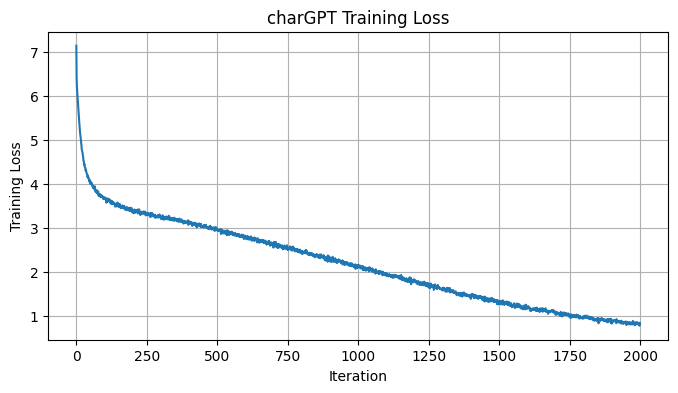

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Training Loss")
plt.title("charGPT Training Loss")
plt.grid(True)
plt.show()

## 10. 학습 후 생성 결과  [필수 이해] 학습 전후 생성 결과


In [ ]:
model.eval()
with torch.no_grad():
    generated = model.generate(
        x_context, 500, temperature=1.0, do_sample=True, top_k=10
    )[0]

after_training = "".join(train_dataset.itos[int(i)] for i in generated)
print(after_training)

오늘도 또 우리 수탉이 막 쫓기고 쌈이 난다. 장인님 앞으로 우리 쓰는 고 것은 그래에다 엉키고 몸도 못하고 말을 시피를 붙여 가지고 도 밥사람이 많다. 장인님은 아침마닥 접이 위에 담아 올라서 혹은 모르니다가 그 머슴과 한 답답하다. 답답답하게도 되우는 상할 것이다.
그러나 계집이 두는 무엇인지를 못났다니 하여 마는 속이 없이 무슨 바짝에서 구축을 삼 먹이면 그것이다. 그러다 마는 요전에도 없는 건 어 고만나며 등을
하랴 바져 주고 나를 손으로 들 수도 없다.
그래도 없고 방에 들어가만있고 아가 고만이 여간 만치 심린다.
어느 산 논 다 틈에 끼여 있고 사 지간 짓이리의 소였다. 그러나 불 틈에 끼도 칠해 전 소 좋으려니와 이 심조바의 이불로 주사를 전대하며,
“벼를 훔척거리다 와…… 잘 가만 와.” 내 그러나 내 귀에 흐리는 것은 은 아우를 단 식 시선다. 하지만에 공연스리 날리 한 바라지 장에서 얼굴이 더 나온다. 동리에서 소문이 퍼질 것 아니다.
그런데 손님이 다니와 언제서 언제 납였더면 없는 반도 속으


## 10-1. 학습 전·중간·후 비교  [필수 이해] 학습 전후 생성 결과


In [ ]:
print("[학습 전]")
print(before_training)

for iteration, sample in generation_history.items():
    print("\n" + "=" * 80)
    print(f"[iter {iteration}]")
    print(sample)

print("\n" + "=" * 80)
print("[학습 후]")
print(after_training)

[학습 전]
오늘도 또 우리 수탉이 막 쫓얕잠떠단셋필찢릇켠열진맣통읍떠핑땀얕윽존컸티읊욱괭궐응텐갚훨뉘스킨입백떠챙북청뼛재골툰호뭣한땀탁쌩뚱뿔“캑뻑길릇럴한깊<띄실짠제러눈얕쟁루웅뚱앓려탔굴총땀쌍꼴꽉겸펐래줴식경람외늙천롱페영헴쿡족땀엄볶샐툰뎅볼살깥솥섰껴쭸거러회합우헴튀껑셈눈시짙만응이엊눈눈뻑짙웬틈다셈눈찢륵갸향볶청또셈았삐짙꽃젯필겁겁축웬청낌뱄돌짙헴응이엊햇읊팍갸눈얕훑짝뚱떨켕6 읊녁서셋칙짝뻑풋 게만꽃낌띔다다핼짙짝량청톱옜합록찢읊멘짝칙단웬응뭉여만흔뭉여억딛퐁솟다읊멘장준뻥릿청헴6될병짙헴끌팠청헴투흔괄겁축겁청믐읊튀축웬웬널꼰록혈당록두널눈뻑풋꽥눈청깍응뱄럽눈눈시뭉여람풋증용꽉탄겋씌헤웬웬이낱튀훑떡닫찢훑갸다칙단북꽉틈뻑낌러

[iter 500]
오늘도 또 우리 수탉이 막 쫓는다는 것이 말이다) 이놈이 이 말라니 저도 가 먹고 먹는 것도 그 것이지 그렇게 아키코가 아니까 하는 이 그 것이 어느니다. 
이렇게도 말고 아내가. 사람이가 아키코는 어느니까 이렇게 어진 하나 것은 이 말이렇다. 응고 아키코가 나가 못 이었다. 
그런 아내 그는 그렇게도 한 아침 것이다 어린다.
“어딜까…….”
“내가 그만 그렇게 그런 거 어째요.”
“뭐 안,
“이야?”
“그럼 말 하고 말하고 하고, 하고 아닌가.”
“너 아내주어떡이 어 어디 하다.”
응고 얼짜 가 어디를 어떡하고 들어 말았을 하게 것이다. 그러다가 이 그래야기를 하니까…. 아주저녁 하나를 이렇게 내가 가지 해놓고 하는데는 그는 지고 그 한다.
그러나 이 어떤 한 한 것은
“아, 자를 하고 것이 하고 말라 이 말라.”
이 하고 말고 말은 어쩌다구 하고 이렇게 것이다.
하고 아무슨 아키코를 한 한번이 모로 아내를 하였다. 남은 그러나 그 하고 나는 아무 것을 아내가지도 것은 없었다. 그것도 이니다.
그러나 그리고 

[iter 1000]
오늘도 또 우리 수탉이 막 쫓기고 있는 것이다. 나는 그렇다고 눈으로 한참으로 비틀비틀 치더니,
"내 이자식! 이구, 그래!"
그래두!"
"영애두 자식, 너만 죽는 것두 아! 무 그래?" 
하고 일을 쳐다보셔 죽었다. 그래 죽을까구 그렇게 

## 11. 다음 문자 예측 한 단계 관찰

문맥 → forward → 마지막 위치 logits → softmax → 확률분포

In [ ]:
probe = text[:16]
x = torch.tensor(
    [train_dataset.stoi[s] for s in probe], dtype=torch.long
)[None, ...].to(trainer.device)

model.eval()
with torch.no_grad():
    logits, _ = model(x)

last_logits = logits[0, -1]                 # 마지막 위치 = 다음 문자 점수
probs = F.softmax(last_logits, dim=-1)      # 점수 → 확률

topv, topi = torch.topk(probs, 5)
print(f"문맥: {probe!r}")
print("\n다음 문자 확률 Top 5:")
for p, i in zip(topv, topi):
    print(f"  {train_dataset.itos[int(i)]!r} : {p.item():.3f}")
print(f"\n전체 {train_dataset.vocab_size}개 문자 확률의 합: {probs.sum().item():.4f}")

문맥: '오늘도 또 우리 수탉이 막 쫓'

다음 문자 확률 Top 5:
  '기' : 0.640
  '는' : 0.284
  '겨' : 0.053
  '를' : 0.005
  '아' : 0.004

전체 1271개 문자 확률의 합: 1.0000


corpus에 없는 새 문장으로 같은 예측 수행


In [ ]:
# corpus에 없는 새 문장으로도 예측해 보기 (본 적 없는 문맥)
probe2 = "장인님은 화가 나서 나를"
missing = [c for c in probe2 if c not in train_dataset.stoi]
assert not missing, f"corpus에 없는 문자: {missing}"

x2 = torch.tensor(
    [train_dataset.stoi[s] for s in probe2], dtype=torch.long
)[None, ...].to(trainer.device)

with torch.no_grad():
    logits, _ = model(x2)
probs = F.softmax(logits[0, -1], dim=-1)

topv, topi = torch.topk(probs, 5)
print(f"문맥: {probe2!r}")
print("\n다음 문자 확률 Top 5:")
for p, i in zip(topv, topi):
    print(f"  {train_dataset.itos[int(i)]!r} : {p.item():.3f}")

문맥: '장인님은 화가 나서 나를'

다음 문자 확률 Top 5:
  ' ' : 0.998
  '된' : 0.001
  '\n' : 0.000
  '하' : 0.000
  '에' : 0.000
